<a href="https://colab.research.google.com/github/KevintheChris/non-voters-eua/blob/main/Eleitores_eua.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **O que é considerado "ser americano" para o eleitor dos EUA?**

Este projeto analisa as perceções dos cidadãos dos Estados Unidos sobre o que significa ser um "bom americano". Utilizando dados de pesquisas, exploramos como diferentes atitudes — como votar, protestar ou exibir a bandeira — são valorizadas por diferentes perfis de eleitores (frequentes, esporádicos e não-eleitores).

**Objetivos desta etapa:**
1. Importar as bibliotecas necessárias para análise e visualização.
2. Carregar a base de dados.
3. Fazer uma inspeção inicial para entender a estrutura dos nossos dados.

In [2]:
# 1. Importação das bibliotecas necessárias
import pandas as pd # Para manipulação de tabelas e dados
import matplotlib.pyplot as plt # Para criação de gráficos base
import seaborn as sns # Para gráficos estatísticos mais bonitos e fáceis de usar
import warnings
warnings.filterwarnings('ignore') # Ignora todos os avisos (warnings)


# Configuração visual padrão para os gráficos do seaborn
sns.set_theme(style="whitegrid")

# 2. Carregamento da base de dados
caminho_arquivo = 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/non-voters/nonvoters_data.csv'

df = pd.read_csv(caminho_arquivo)

# Exibe as primeiras 5 linhas para termos a certeza que está tudo correto
display(df.head())

# Exibe informações sobre as colunas e tipos de dados
print("\nInformações do Dataset:")
display(df.info())


,RespId,weight,Q1,Q2_1,Q2_2,Q2_3,Q2_4,Q2_5,Q2_6,Q2_7,...,Q30,Q31,Q32,Q33,ppage,educ,race,gender,income_cat,voter_category
0,470001,0.7516,1,1,1,2,4,1,4,2,...,2,NaN,1.0,NaN,73,College,White,Female,$75-125k,always
1,470002,1.0267,1,1,2,2,3,1,1,2,...,3,NaN,NaN,1.0,90,College,White,Female,$125k or more,always
2,470003,1.0844,1,1,1,2,2,1,1,2,...,2,NaN,2.0,NaN,53,College,White,Male,$125k or more,sporadic
3,470007,0.6817,1,1,1,1,3,1,1,1,...,2,NaN,1.0,NaN,58,Some college,Black,Female,$40-75k,sporadic
4,480008,0.9910,1,1,1,-1,1,1,1,1,...,1,-1.0,NaN,NaN,81,High school or less,White,Male,$40-75k,always



Informações do Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5836 entries, 0 to 5835
Columns: 119 entries, RespId to voter_category
dtypes: float64(23), int64(91), object(5)
memory usage: 5.3+ MB


None

## PARTE 1 - O Público da Pesquisa 👥

Antes de entendermos o que os eleitores pensam, precisamos de entender **quem** eles são. Nesta secção, vamos explorar o perfil demográfico da nossa amostra.

**Perguntas que vamos responder:**
1. Qual é a distribuição de idade, género, raça, nível educacional e salarial?
2. Qual raça possui maior e menor poder aquisitivo?
3. Existe uma correlação (relação) entre o nível educacional e o poder aquisitivo?

Para garantir a melhor visualização dos dados, utilizaremos tabelas de frequência (absoluta e relativa), gráficos de barras de contagem e boxplots, evitando gráficos de pizza que dificultam a comparação de proporções.


Para entender quem são os eleitores desta pesquisa, vamos analisar a distribuição das principais variáveis demográficas.

**Metodologia Visual:**
* **Variáveis Categóricas (Gênero, Raça, Educação, Renda):** Utilizaremos gráficos de barras de contagem (`countplot`). Eles são ideais porque permitem comparar rapidamente o volume de cada categoria através do comprimento das barras, evitando a distorção visual que os gráficos de pizza costumam causar. Acompanharemos com tabelas de frequência absoluta (contagem total) e relativa (percentual).
* **Variável Numérica (Idade):** Utilizaremos um `boxplot` (diagrama de caixa). Este gráfico é excelente para mostrar a distribuição da idade, revelando onde está a maioria dos eleitores (a "caixa" central), a mediana (a linha no meio) e possíveis pontos fora da curva (outliers).

--- TABELAS DE FREQUÊNCIA ---

Distribuição de gender:


,Absoluta,Percentual (%)
gender,,
Male,2940,50.38
Female,2896,49.62


----------------------------------------
Distribuição de race:


,Absoluta,Percentual (%)
race,,
White,3710,63.57
Black,932,15.97
Hispanic,813,13.93
Other/Mixed,381,6.53


----------------------------------------
Distribuição de educ:


,Absoluta,Percentual (%)
educ,,
College,2330,39.92
High school or less,1796,30.77
Some college,1710,29.30


----------------------------------------
Distribuição de income_cat:


,Absoluta,Percentual (%)
income_cat,,
$75-125k,1628,27.90
Less than $40k,1418,24.30
$40-75k,1396,23.92
$125k or more,1394,23.89


----------------------------------------


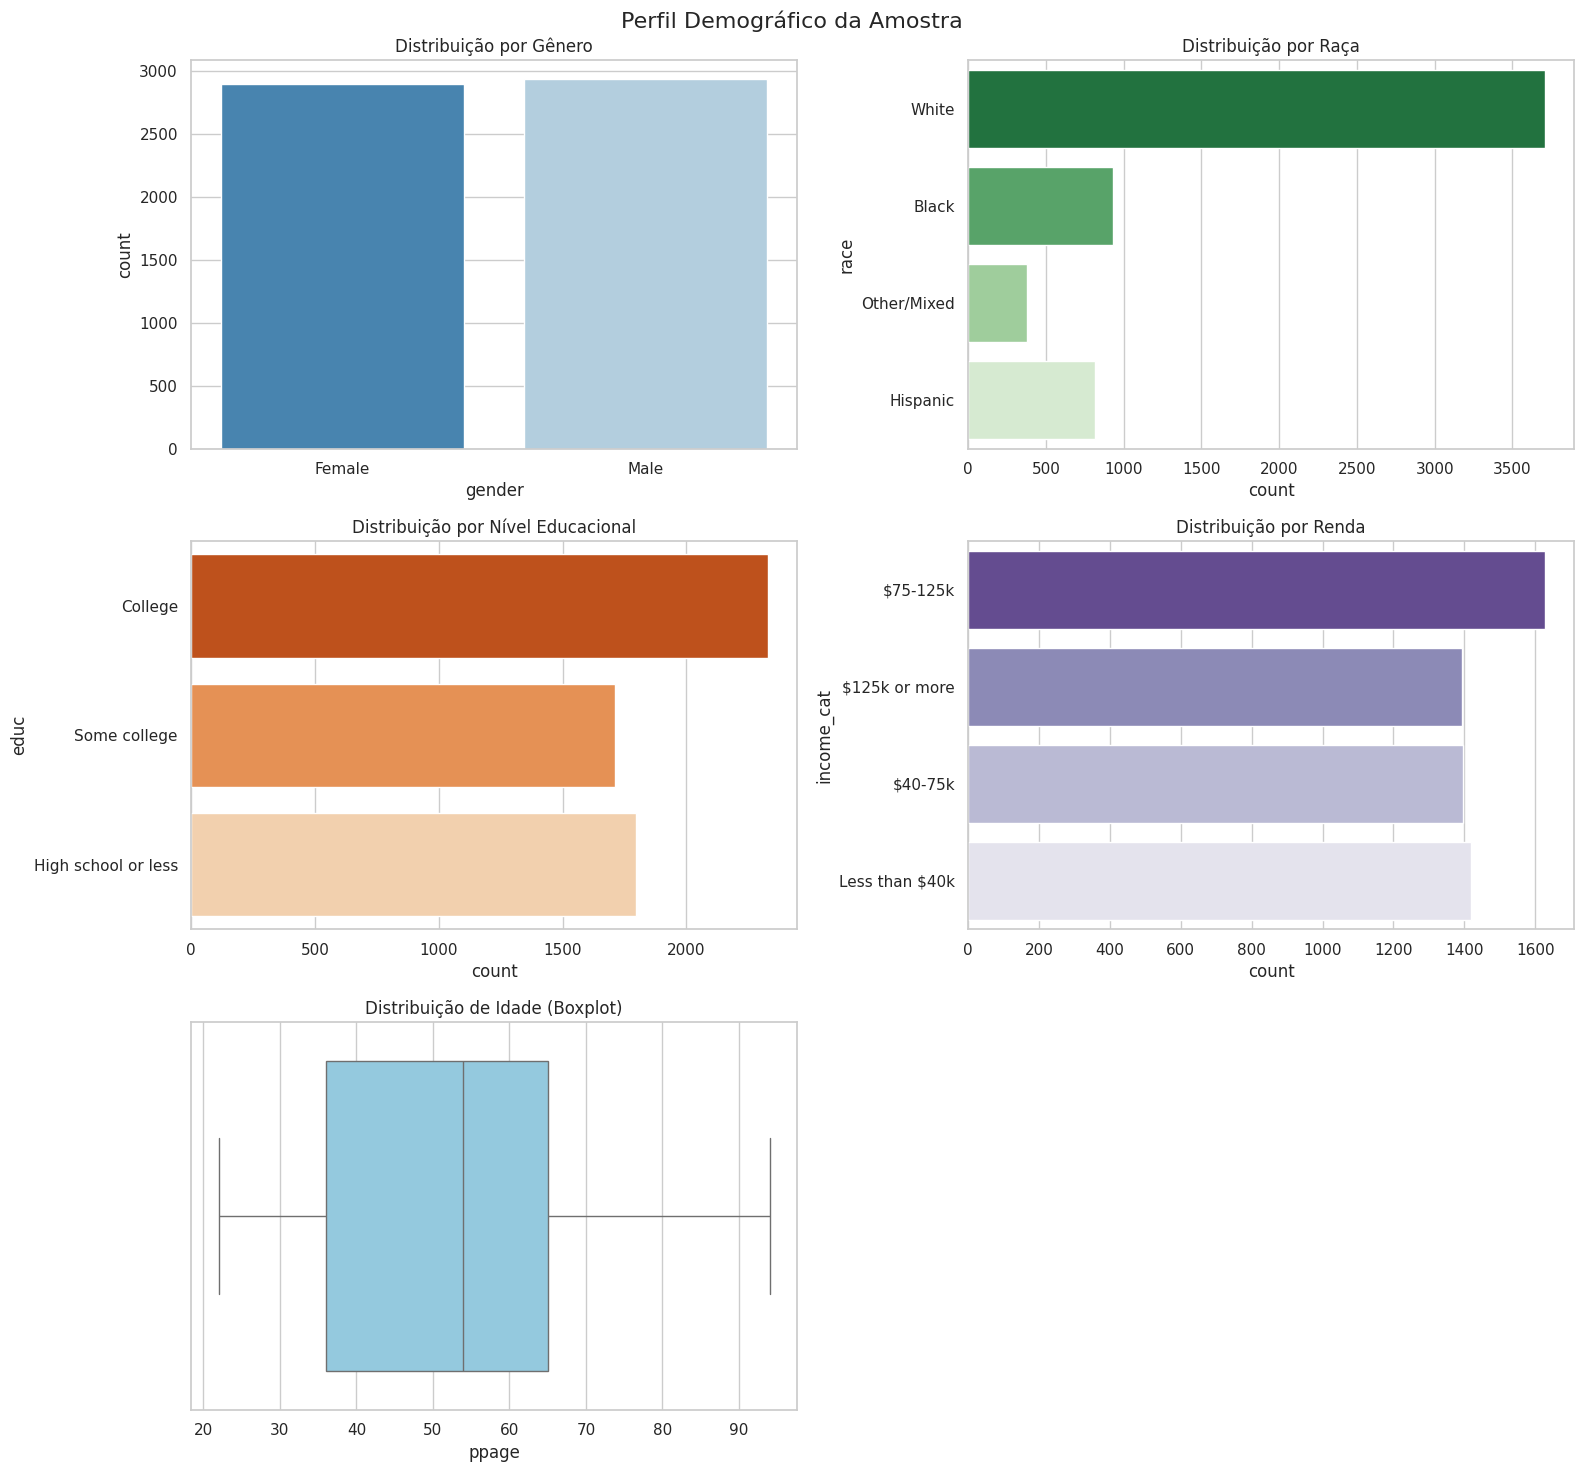

In [3]:
# 1. Tabela de Frequência Absoluta e Relativa para as variáveis categóricas
variaveis_categoricas = ['gender', 'race', 'educ', 'income_cat']

print("--- TABELAS DE FREQUÊNCIA ---\n")
for col in variaveis_categoricas:
    # Frequência Absoluta
    freq_abs = df[col].value_counts()
    # Frequência Relativa (multiplicado por 100 para virar percentual)
    freq_rel = df[col].value_counts(normalize=True) * 100

    # Juntando as duas numa única tabela
    tabela_freq = pd.DataFrame({'Absoluta': freq_abs, 'Percentual (%)': freq_rel})
    print(f"Distribuição de {col}:")
    display(tabela_freq.round(2)) # round(2) para deixar apenas 2 casas decimais
    print("-" * 40)

# 2. Visualização das Distribuições (Gráficos)
# Criando uma figura com vários espaços (subplots) para organizar os gráficos
fig, axes = plt.subplots(3, 2, figsize=(16, 15))
fig.suptitle('Perfil Demográfico da Amostra', fontsize=16)

# Gráficos de barras de contagem (Countplots)
sns.countplot(data=df, x='gender', ax=axes[0, 0], palette='Blues_r')
axes[0, 0].set_title('Distribuição por Gênero')

sns.countplot(data=df, y='race', ax=axes[0, 1], palette='Greens_r')
axes[0, 1].set_title('Distribuição por Raça')

sns.countplot(data=df, y='educ', ax=axes[1, 0], palette='Oranges_r')
axes[1, 0].set_title('Distribuição por Nível Educacional')

sns.countplot(data=df, y='income_cat', ax=axes[1, 1], palette='Purples_r')
axes[1, 1].set_title('Distribuição por Renda')

# Gráfico de distribuição para Idade (Boxplot)
sns.boxplot(data=df, x='ppage', ax=axes[2, 0], color='skyblue')
axes[2, 0].set_title('Distribuição de Idade (Boxplot)')

# Escondendo o último gráfico vazio (já que temos 5 variáveis e 6 espaços)
axes[2, 1].axis('off')

plt.tight_layout()
plt.show()

### Relação entre Raça e Poder Aquisitivo

Assumindo que a amostra é representativa, vamos analisar a distribuição de renda dentro de cada grupo racial.

**Metodologia Visual:**
Utilizaremos um gráfico de barras agrupadas juntamente com uma tabela cruzada de frequência relativa. Ao calcular a proporção de cada faixa salarial *dentro* de cada raça, conseguimos comparar os grupos de forma justa, independentemente de um grupo ter mais respondentes totais do que o outro.

Frequência Relativa (%) de Renda dentro de cada Raça:


income_cat,$125k or more,$40-75k,$75-125k,Less than $40k
race,,,,
Black,13.63,26.18,24.36,35.84
Hispanic,19.43,24.97,28.41,27.18
Other/Mixed,33.07,19.95,26.25,20.73
White,26.50,23.53,28.84,21.13


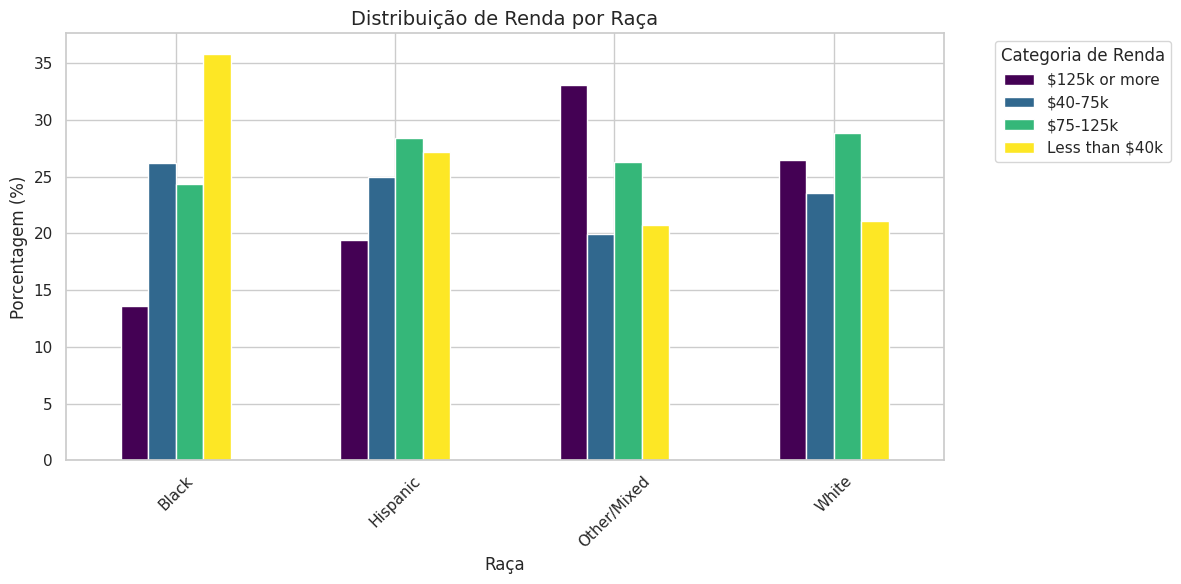

In [4]:
# Tabela cruzada (Crosstab) com frequência relativa por linha (normalize='index')
# Isso mostra a % de cada renda DENTRO de cada raça
renda_por_raca = pd.crosstab(df['race'], df['income_cat'], normalize='index') * 100

print("Frequência Relativa (%) de Renda dentro de cada Raça:")
display(renda_por_raca.round(2))

# Gráfico de barras agrupadas
# figsize aumenta o tamanho para caber a legenda confortavelmente
renda_por_raca.plot(kind='bar', stacked=False, figsize=(12, 6), colormap='viridis')

plt.title('Distribuição de Renda por Raça', fontsize=14)
plt.xlabel('Raça')
plt.ylabel('Porcentagem (%)')
plt.xticks(rotation=45) # Rotaciona os nomes das raças para facilitar a leitura
plt.legend(title='Categoria de Renda', bbox_to_anchor=(1.05, 1), loc='upper left') # Coloca a legenda fora do gráfico
plt.tight_layout()
plt.show()

### Correlação entre Nível Educacional e Poder Aquisitivo

Será que estudar mais reflete diretamente em maiores rendas nesta amostra? Para responder, vamos cruzar o nível de escolaridade com a categoria de renda.

**Metodologia Visual:**
Assim como na análise racial, a tabela de contingência e o gráfico de barras agrupadas são as ferramentas mais adequadas. Eles permitem visualizar se a proporção de pessoas nas faixas de renda mais altas aumenta progressivamente à medida que avançamos nos níveis educacionais.

Frequência Relativa (%) de Renda dentro de cada Nível Educacional:


income_cat,$125k or more,$40-75k,$75-125k,Less than $40k
educ,,,,
College,40.94,18.15,32.92,7.98
High school or less,8.35,28.62,19.49,43.54
Some college,16.96,26.84,29.88,26.32


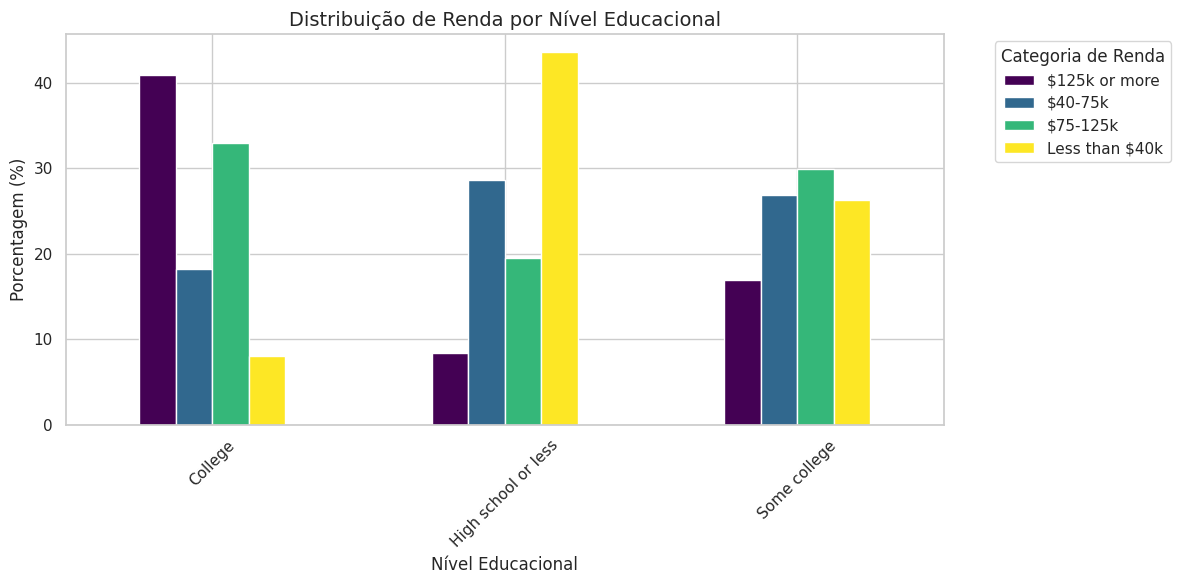

In [5]:
# Tabela cruzada com frequência relativa por linha
renda_por_educ = pd.crosstab(df['educ'], df['income_cat'], normalize='index') * 100

print("Frequência Relativa (%) de Renda dentro de cada Nível Educacional:")
display(renda_por_educ.round(2))

# Gráfico de barras agrupadas
renda_por_educ.plot(kind='bar', stacked=False, figsize=(12, 6), colormap='viridis')

plt.title('Distribuição de Renda por Nível Educacional', fontsize=14)
plt.xlabel('Nível Educacional')
plt.ylabel('Porcentagem (%)')
plt.xticks(rotation=45)
plt.legend(title='Categoria de Renda', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## PARTE 2 - O QUE É CONSIDERADO SER UM BOM AMERICANO
### Um nível educacional maior implica em maior responsabilidade em relação a votar?

Para responder a esta pergunta, vamos cruzar a variável de nível educacional (`EDUC`) com a variável `Q2_1` (que mede a importância de "Votar em eleições" para ser um bom americano).

**Lógica de Análise:**
Na pesquisa, a resposta `1` indica "Muito importante" e `4` indica "Nada importante". Vamos criar uma tabela de frequência relativa para ver a percentagem de pessoas em cada nível educacional que considera o voto "Muito importante". Utilizaremos um gráfico de barras para visualizar essa tendência.

Frequência Relativa (%): Importância do Voto por Nível Educacional


Q2_1,-1,1,2,3,4
educ,,,,,
College,0.26,87.85,10.00,1.24,0.64
High school or less,1.28,72.55,17.20,3.73,5.23
Some college,0.35,82.34,11.46,2.87,2.98


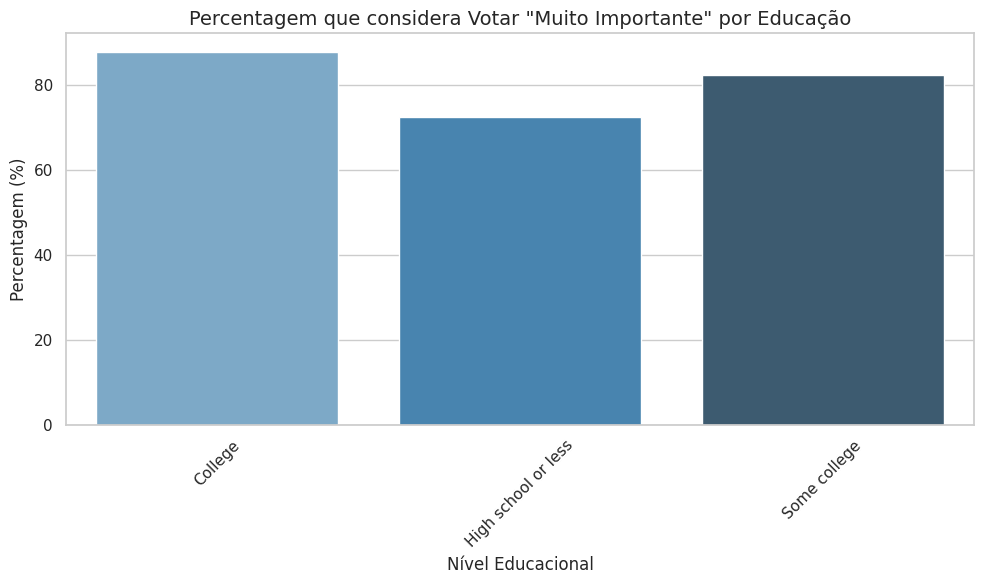

In [6]:
# Tabela cruzada: Nível Educacional x Importância de Votar (Q2_1)
# normalize='index' calcula a percentagem dentro de cada linha (nível educacional)
voto_por_educacao = pd.crosstab(df['educ'], df['Q2_1'], normalize='index') * 100

print("Frequência Relativa (%): Importância do Voto por Nível Educacional")
display(voto_por_educacao.round(2))

# Vamos focar na resposta '1' (Muito importante) para ver se cresce com a educação
# Assumindo que a coluna 1 representa "Muito importante"
plt.figure(figsize=(10, 6))
# Filtramos apenas a coluna referente à resposta 1
sns.barplot(x=voto_por_educacao.index, y=voto_por_educacao[1], palette='Blues_d')

plt.title('Percentagem que considera Votar "Muito Importante" por Educação', fontsize=14)
plt.xlabel('Nível Educacional')
plt.ylabel('Percentagem (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Dentre os não-brancos, o que é mais importante: Votar, a Bandeira ou o Exército?

Primeiro, vamos isolar os respondentes não-brancos da nossa amostra. Em seguida, vamos comparar a percentagem de pessoas neste grupo que avaliou como "Muito importante" (resposta 1):
* Votar em eleições (`Q2_1`)
* Exibir a bandeira americana (`Q2_4`)
* Apoiar os militares (`Q2_7`)

Na segunda etapa, vamos quebrar essas mesmas métricas pelo nível de renda (`INCOME_CAT`) para ver se o poder aquisitivo altera as prioridades dentro deste grupo demográfico. Utilizaremos gráficos de barras agrupadas para facilitar a comparação lado a lado.

--- Geral Não-Brancos: Percentagem que considera 'Muito Importante' ---


,Atitude,Percentagem
0,Votar (Q2_1),80.10
1,Bandeira (Q2_4),25.35
2,Exército (Q2_7),57.38



--- Não-Brancos por Renda: Percentagem que considera 'Muito Importante' ---


,Votar,Bandeira,Exército
income_cat,,,
$125k or more,87.35,19.22,54.26
$40-75k,78.20,26.58,57.17
$75-125k,84.05,22.22,57.89
Less than $40k,73.50,31.07,59.15


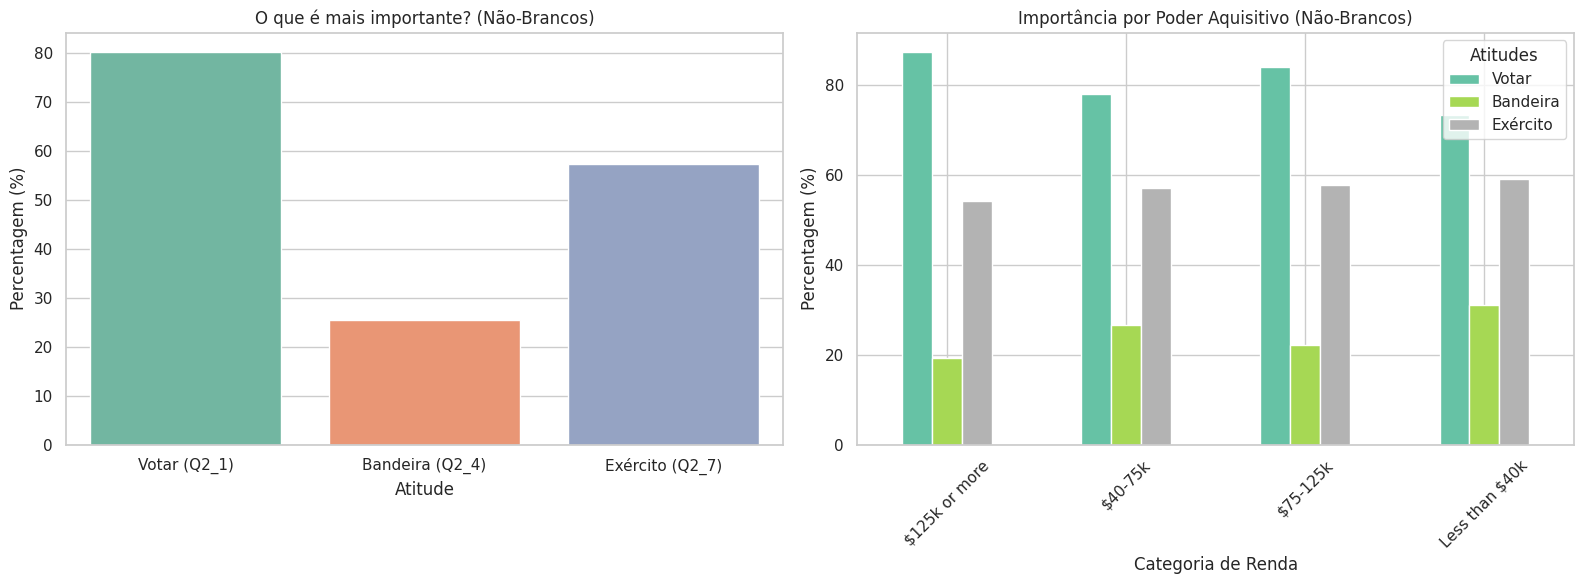

In [7]:
# 1. Filtrar o dataset para Não-Brancos
df_nao_brancos = df[df['race'] != 'White']

# 2. Calcular a percentagem de "Muito importante" (valor == 1) para o grupo todo
importancia_geral = {
    'Votar (Q2_1)': (df_nao_brancos['Q2_1'] == 1).mean() * 100,
    'Bandeira (Q2_4)': (df_nao_brancos['Q2_4'] == 1).mean() * 100,
    'Exército (Q2_7)': (df_nao_brancos['Q2_7'] == 1).mean() * 100
}

# Criar um DataFrame simples para o gráfico geral
df_importancia_geral = pd.DataFrame(list(importancia_geral.items()), columns=['Atitude', 'Percentagem'])

print("--- Geral Não-Brancos: Percentagem que considera 'Muito Importante' ---")
display(df_importancia_geral.round(2))

# 3. Calcular a mesma percentagem, mas agrupada por Renda (income_cat)
# Agrupamos por renda e calculamos a média de vezes que a resposta foi 1 (transformando o booleano em 0 ou 1)
renda_nao_brancos = df_nao_brancos.groupby('income_cat')[['Q2_1', 'Q2_4', 'Q2_7']].apply(lambda x: (x == 1).mean() * 100)
renda_nao_brancos.columns = ['Votar', 'Bandeira', 'Exército']

print("\n--- Não-Brancos por Renda: Percentagem que considera 'Muito Importante' ---")
display(renda_nao_brancos.round(2))

# 4. Visualizações
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Geral
sns.barplot(data=df_importancia_geral, x='Atitude', y='Percentagem', ax=axes[0], palette='Set2')
axes[0].set_title('O que é mais importante? (Não-Brancos)')
axes[0].set_ylabel('Percentagem (%)')

# Gráfico 2: Por Renda
renda_nao_brancos.plot(kind='bar', ax=axes[1], colormap='Set2')
axes[1].set_title('Importância por Poder Aquisitivo (Não-Brancos)')
axes[1].set_ylabel('Percentagem (%)')
axes[1].set_xlabel('Categoria de Renda')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Atitudes')

plt.tight_layout()
plt.show()

### Qual geração é mais tolerante?

Considerando que respeitar a opinião de quem discorda de nós (`Q2_8`) é um indício de tolerância, vamos comparar diferentes gerações.

**Lógica de Análise:**
A nossa variável de idade (`PPAGE`) é contínua. Vamos usar uma função do Pandas chamada `cut()` para "fatiar" essas idades em três categorias específicas: 18-30 anos, 31-50 anos e 51+ anos. Depois, vamos cruzar essas faixas etárias com as respostas da `Q2_8` usando uma tabela de frequência e um gráfico de barras empilhadas para ver qual geração possui a maior taxa de respostas "Muito importante".

Frequência Relativa (%): Tolerância (Q2_8) por Faixa Etária


Q2_8,-1,1,2,3,4
Faixa_Etaria,,,,,
18-30 anos,0.30,51.26,38.83,7.89,1.72
31-50 anos,0.31,58.02,34.31,5.68,1.68
+51 anos,0.55,63.56,30.95,3.95,0.99


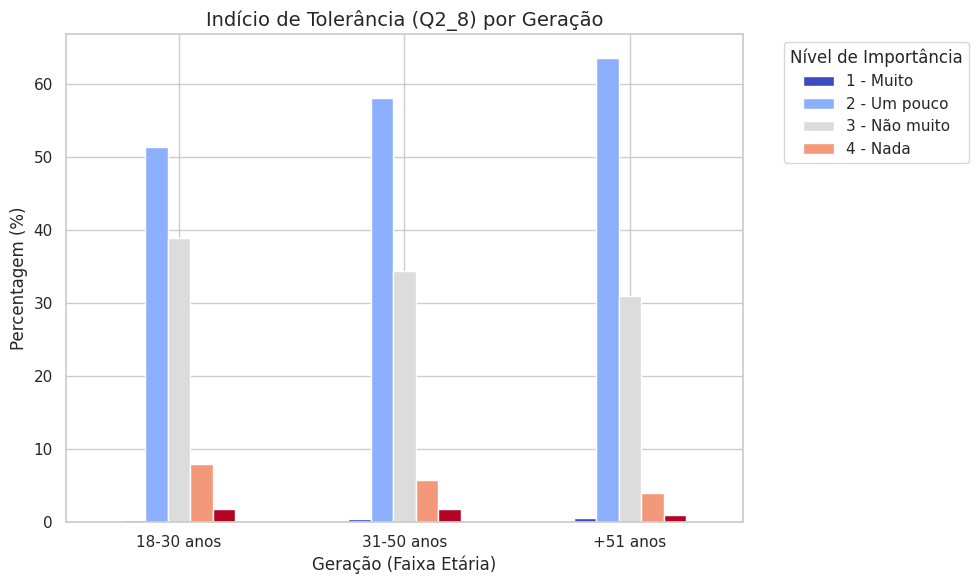

In [8]:
# 1. Criar as faixas etárias
# Os limites (bins) são: 17 (para incluir o 18), 30, 50, e 120 (um limite superior alto para pegar todos os 51+)
limites = [17, 30, 50, 120]
rotulos = ['18-30 anos', '31-50 anos', '+51 anos']

# O pd.cut categoriza a coluna numérica PPAGE nessas faixas
df['Faixa_Etaria'] = pd.cut(df['ppage'], bins=limites, labels=rotulos)

# 2. Tabela de frequência relativa: Faixa Etária vs Tolerância (Q2_8)
tolerancia_por_idade = pd.crosstab(df['Faixa_Etaria'], df['Q2_8'], normalize='index') * 100

print("Frequência Relativa (%): Tolerância (Q2_8) por Faixa Etária")
# Lembrando: 1 = Muito importante (Mais tolerante), 4 = Nada importante (Menos tolerante)
display(tolerancia_por_idade.round(2))

# 3. Visualização com Gráfico de Barras
# Plotamos todas as categorias de resposta para ver o espetro completo
tolerancia_por_idade.plot(kind='bar', stacked=False, figsize=(10, 6), colormap='coolwarm')

plt.title('Indício de Tolerância (Q2_8) por Geração', fontsize=14)
plt.xlabel('Geração (Faixa Etária)')
plt.ylabel('Percentagem (%)')
plt.xticks(rotation=0)
# A legenda assume os valores 1, 2, 3, 4 da pesquisa
plt.legend(title='Nível de Importância', labels=['1 - Muito', '2 - Um pouco', '3 - Não muito', '4 - Nada'], bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## PARTE 3 - ESCOLHAS PARTIDÁRIAS
### Perfil Demográfico por Escolha Partidária (Idade e Gênero)

Nesta etapa, queremos descobrir:
1. Qual escolha partidária possui eleitores mais jovens?
2. Qual possui proporcionalmente mais mulheres como apoiadoras?
3. Qual o perfil de democratas, republicanos e do público sem partido (independentes/sem preferência)?

**Metodologia Visual e Tratamento de Dados:**
* **Mapeamento de Variáveis:** Primeiro, vamos transformar os números da pergunta `Q30` (1 a 5) nos nomes reais dos partidos para facilitar a leitura dos gráficos.
* **Idade vs. Partido:** Utilizaremos um **Boxplot**. Este gráfico é perfeito para ver a distribuição de idades dentro de cada partido. A linha central da caixa mostrar-nos-á a mediana de idade (onde se concentra o "meio" da amostra), revelando rapidamente qual grupo é o mais jovem.
* **Gênero vs. Partido:** Criaremos uma **Tabela de Frequência Relativa** cruzada (`crosstab`), calculando a percentagem de homens e mulheres *dentro* de cada grupo partidário. Em seguida, usaremos um **Gráfico de Barras Agrupadas** para visualizar qual partido atrai mais o público feminino.

--- Frequência Relativa (%): Gênero dentro de cada Escolha Partidária ---


gender,Female,Male
Partido,,
Democrata,54.25,45.75
Independente,39.02,60.98
Outro partido,28.28,71.72
Republicano,50.88,49.12
Sem preferência,57.76,42.24


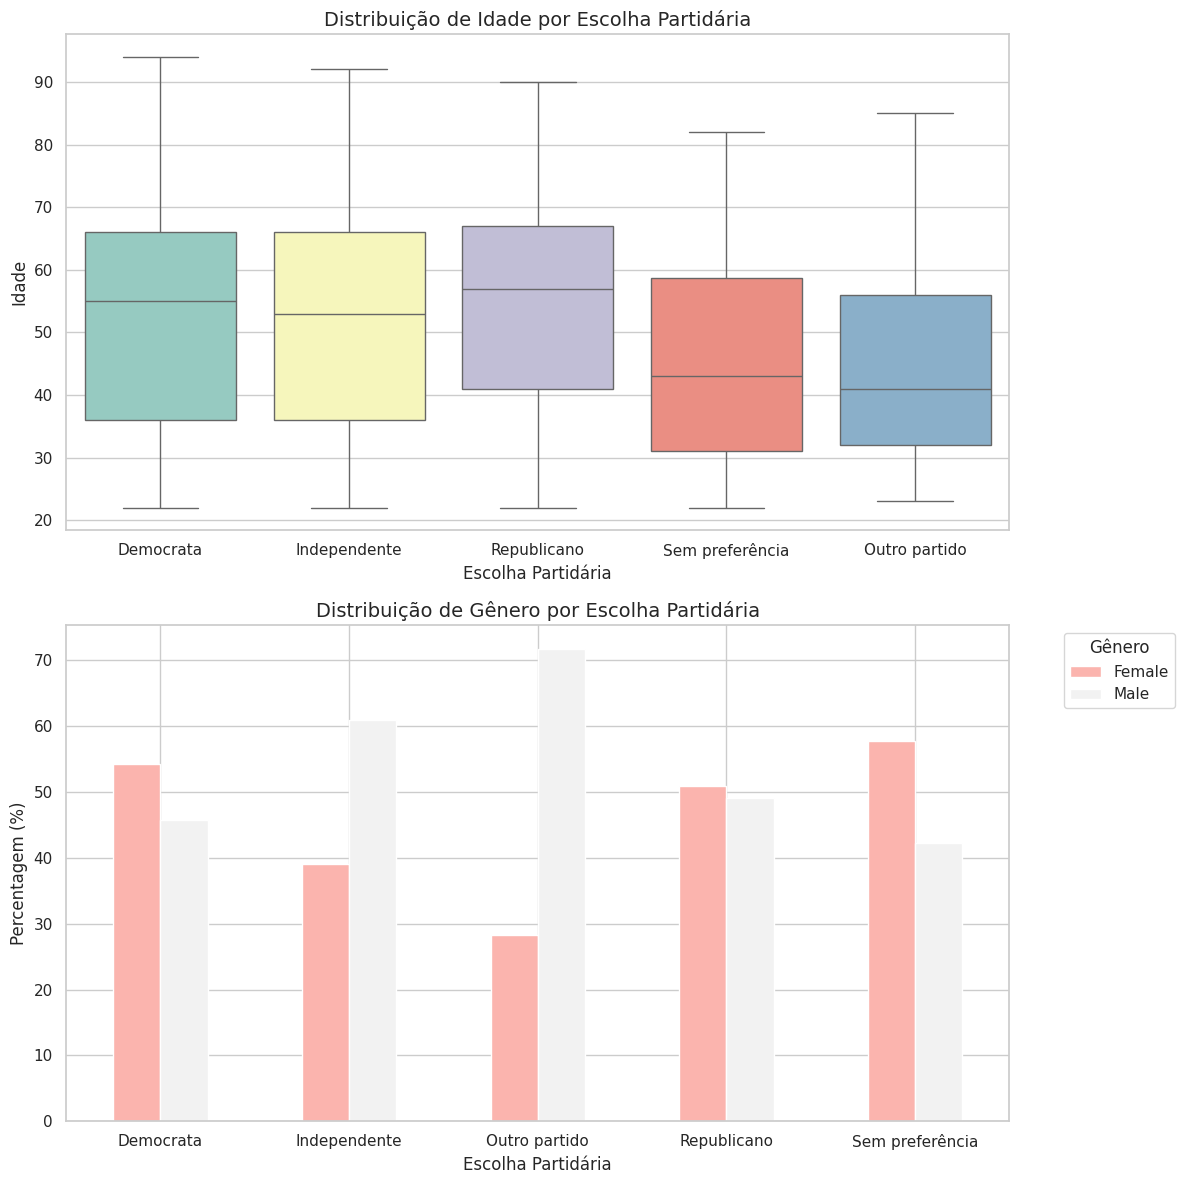

In [9]:
# 1. Preparação dos Dados: Mapear os valores numéricos da Q30 para textos descritivos
mapa_partidos = {
    1: 'Republicano',
    2: 'Democrata',
    3: 'Independente',
    4: 'Outro partido',
    5: 'Sem preferência'
}
# Criamos uma nova coluna chamada 'Partido' para não alterar a original
df['Partido'] = df['Q30'].map(mapa_partidos)

# 2. Análise de Gênero por Partido (Frequência Relativa)
# normalize='index' garante que a soma dos gêneros dentro de cada partido seja 100%
genero_por_partido = pd.crosstab(df['Partido'], df['gender'], normalize='index') * 100

print("--- Frequência Relativa (%): Gênero dentro de cada Escolha Partidária ---")
display(genero_por_partido.round(2))

# 3. Visualizações
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# Gráfico A: Boxplot para Idade por Partido
sns.boxplot(data=df, x='Partido', y='ppage', ax=axes[0], palette='Set3')
axes[0].set_title('Distribuição de Idade por Escolha Partidária', fontsize=14)
axes[0].set_xlabel('Escolha Partidária')
axes[0].set_ylabel('Idade')

# Gráfico B: Gráfico de Barras Agrupadas para Gênero por Partido
genero_por_partido.plot(kind='bar', ax=axes[1], colormap='Pastel1')
axes[1].set_title('Distribuição de Gênero por Escolha Partidária', fontsize=14)
axes[1].set_xlabel('Escolha Partidária')
axes[1].set_ylabel('Percentagem (%)')
axes[1].tick_params(axis='x', rotation=0) # Mantém os nomes dos partidos na horizontal
axes[1].legend(title='Gênero', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Existe uma correlação entre idade e propensão a votos?

Para verificar se a idade influencia a frequência com que o eleitor vai às urnas, vamos cruzar a idade (`PPAGE`) com o perfil de votação (`VOTER_CATEGORY`).

**Metodologia Visual:**
A melhor abordagem aqui é combinar dois gráficos num só: o **Boxplot** para vermos os quartis e a mediana de idade de cada categoria, sobreposto com um **Swarmplot** (gráfico de enxame), que plota os pontos individuais dos eleitores. Essa combinação é excelente porque o Boxplot dá-nos o rigor estatístico, enquanto o Swarmplot mostra-nos exatamente como os dados reais estão espalhados, oferecendo uma visão completa da distribuição (como sugerido nas observações do projeto).

--- Média e Mediana de Idade por Categoria de Voto ---


,mean,median
voter_category,,
always,56.7,62.0
sporadic,53.5,54.0
rarely/never,42.3,38.0


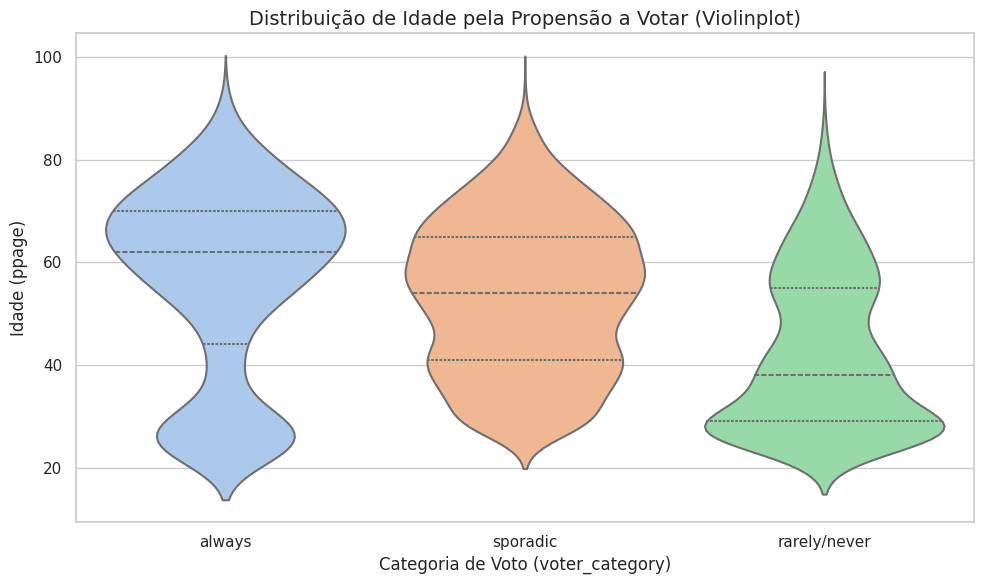

In [10]:
# Definindo a ordem das categorias para fazer sentido cronológico/lógico no gráfico
ordem_votos = ['always', 'sporadic', 'rarely/never']

# Exibir a média e a mediana de idade para cada categoria como apoio numérico
idade_por_categoria = df.groupby('voter_category')['ppage'].agg(['mean', 'median']).round(1)
print("--- Média e Mediana de Idade por Categoria de Voto ---")
display(idade_por_categoria.loc[ordem_votos])

# Criando a visualização otimizada com Violinplot
plt.figure(figsize=(10, 6))

# O Violinplot mostra a densidade da distribuição.
# O parâmetro inner='quartile' desenha linhas pontilhadas representando os quartis e a mediana (o "meio")
sns.violinplot(data=df, x='voter_category', y='ppage', order=ordem_votos,
               palette='pastel', inner='quartile', linewidth=1.5)

plt.title('Distribuição de Idade pela Propensão a Votar (Violinplot)', fontsize=14)
plt.xlabel('Categoria de Voto (voter_category)')
plt.ylabel('Idade (ppage)')

plt.tight_layout()
plt.show()


## PARTE 4 - ESTRATÉGIAS ELEITORAIS
### Qual público o partido republicano deve mirar para atrair mais votos?

Para desenhar uma estratégia de marketing eficiente, precisamos de encontrar o nosso "Público de Oportunidade". Não faz sentido gastar recursos com quem já vota religiosamente no partido. O foco deve ser em **Republicanos e Independentes que votam esporadicamente ou que raramente/nunca votam**. Se conseguirmos convencer este grupo a ir às urnas, o partido ganha novos votos.

**Metodologia Analítica e Visual:**
1. **Filtragem de Dados:** Vamos isolar apenas os eleitores que responderam ser Republicanos ou Independentes (na pergunta `Q30`) E que pertencem às categorias `sporadic` ou `rarely/never` (`VOTER_CATEGORY`).
2. **Perfilamento:** Vamos utilizar gráficos de barras de contagem (`countplot`) para visualizar a distribuição de Renda e Nível Educacional desse grupo específico, e um histograma com curva de densidade para a Idade, revelando exatamente quem são essas pessoas que a equipa de marketing deve focar.

Tamanho total da amostra original: 5836
Tamanho do 'Público de Oportunidade' Republicano: 2020
--------------------------------------------------
Perfil Educacional do Público-Alvo (%):


,proportion
educ,
College,39.31
High school or less,31.39
Some college,29.31



Perfil de Renda do Público-Alvo (%):


,proportion
income_cat,
$75-125k,29.70
$125k or more,25.54
$40-75k,23.61
Less than $40k,21.14


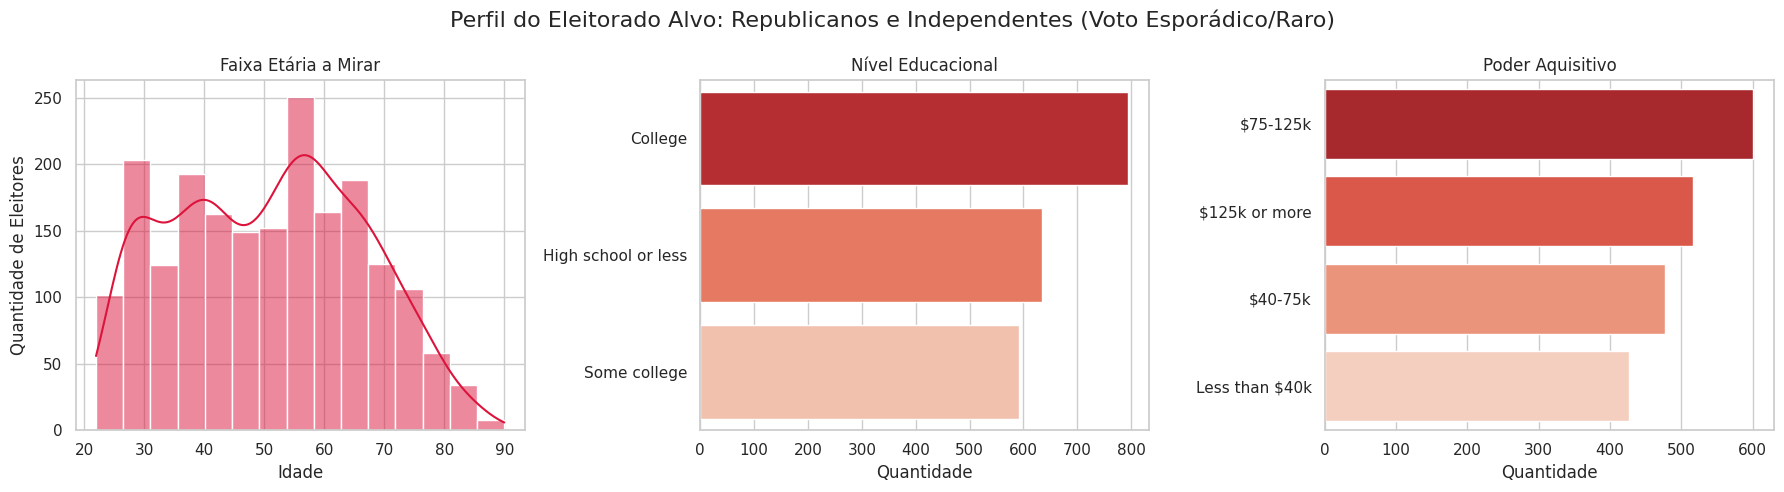

In [12]:
# 1. Filtrar o Público de Oportunidade
# Q30: 1 = Republicano, 3 = Independente
# voter_category: 'sporadic' ou 'rarely/never'
filtro_partido = df['Q30'].isin([1, 3])
filtro_voto = df['voter_category'].isin(['sporadic', 'rarely/never'])

# Cria um novo DataFrame só com o nosso público-alvo
df_alvo_republicano = df[filtro_partido & filtro_voto].copy()

print(f"Tamanho total da amostra original: {len(df)}")
print(f"Tamanho do 'Público de Oportunidade' Republicano: {len(df_alvo_republicano)}")
print("-" * 50)

# 2. Tabelas de Frequência para o Público-Alvo
print("Perfil Educacional do Público-Alvo (%):")
display((df_alvo_republicano['educ'].value_counts(normalize=True) * 100).round(2))

print("\nPerfil de Renda do Público-Alvo (%):")
display((df_alvo_republicano['income_cat'].value_counts(normalize=True) * 100).round(2))

# 3. Visualizações para a Equipa de Marketing
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Perfil do Eleitorado Alvo: Republicanos e Independentes (Voto Esporádico/Raro)', fontsize=16)

# Gráfico A: Distribuição de Idade (Histograma + KDE)
# Usamos histplot aqui em vez de boxplot para ver os "picos" de idade (ex: se há um pico nos 25 anos)
sns.histplot(data=df_alvo_republicano, x='ppage', bins=15, kde=True, ax=axes[0], color='crimson')
axes[0].set_title('Faixa Etária a Mirar')
axes[0].set_xlabel('Idade')
axes[0].set_ylabel('Quantidade de Eleitores')

# Gráfico B: Nível Educacional
sns.countplot(data=df_alvo_republicano, y='educ', ax=axes[1], palette='Reds_r',
              order=df_alvo_republicano['educ'].value_counts().index) # Ordena do maior para o menor
axes[1].set_title('Nível Educacional')
axes[1].set_xlabel('Quantidade')
axes[1].set_ylabel('')

# Gráfico C: Categoria de Renda
sns.countplot(data=df_alvo_republicano, y='income_cat', ax=axes[2], palette='Reds_r',
              order=df_alvo_republicano['income_cat'].value_counts().index)
axes[2].set_title('Poder Aquisitivo')
axes[2].set_xlabel('Quantidade')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

---
## 🎯 Conclusão e Principais Descobertas (Takeaways)

Após analisarmos detalhadamente a base de dados dos eleitores dos EUA, chegamos a várias conclusões valiosas sobre o comportamento e a demografia política:

* **O Perfil Geral e Económico:** Confirmamos que existe uma correlação clara entre o nível educacional e o poder aquisitivo. Eleitores com nível superior (College) tendem a concentrar-se nas faixas de renda mais altas. No recorte racial, observamos que **Brancos e outras raças/mestiços(por incorporar mais pessoas) costumam receber mais do que pessoas negras**.
* **A Visão sobre Ser "Bom Americano":** A atitude de "Votar em eleições" é esmagadoramente valorizada como um dever cívico, crescendo a sua importância à medida que o nível educacional aumenta. Entre os não-brancos, **Votar superou exibir a bandeira ou apoiar o exército** demonstrou ser a atitude mais relevante.
* **Tolerância e Gerações:** Na análise sobre o respeito a opiniões divergentes, os dados revelaram que as **gerações mais velhas apresentam o maior índice de tolerância, enquanto os mais novos apresentou os menores índices**.
* **Comportamento e Escolhas Partidárias:** Descobrimos uma correlação positiva entre a idade e a assiduidade nas urnas: os eleitores mais velhos são os que votam com mais frequência. No que toca a partidos,os jovens não tem muita preferencia de Partido diferente dos mais velhos, e o Partido **Democrata** conta com uma maior proporção de apoio feminino.
* **Estratégia de Marketing Eleitoral:** Para uma campanha Republicana focada em atrair simpatizantes "adormecidos" (que raramente votam), os dados indicam que o alvo ideal e de menor custo de aquisição são os **Eleitores com maior grau de escolaridade e com um poder aquisitivo entre $75-15k(anual).** Focar anúncios digitais neste perfil específico tem o maior potencial de retorno para o partido.

---
*Projeto desenvolvido com Python, Pandas e Seaborn. Análise de Dados para Portifólio.*